# 03 — Exploratory Data Analysis (merged)
**Dataset:** NYC DOF Rolling Sales (Sep 2016 – Aug 2017).
**Input:** `data/nyc_cleaned.parquet` (from `01_cleaning.ipynb`) — keeps `is_market_sale` flag, log price, derived features.

**Problem:** Which NYC boroughs and neighborhoods offer the best value for residential buyers, and what factors most influence sale price?

## Methodological choices (enforced throughout)
- All price/$-per-sqft analyses filtered to `is_market_sale==True` (drops ~15% deed transfers, price < $100).
- Heavy-tailed variables (price, sqft, units) displayed on **log10** axes (linear + 99-pct capping hides real structure).
- Correlations use **Spearman** by default (Pearson biased under extreme skew; skewness of `sale_price` ≈ 20 confirms this).
- Outliers **flagged, not dropped** — `is_outlier_price` preserved upstream.

## Column classification

| Column | Type | Sub-type |
|--------|------|----------|
| `SALE PRICE` | Numerical | Continuous (log-normal) |
| `GROSS SQUARE FEET` | Numerical | Continuous (log-normal) |
| `LAND SQUARE FEET` | Numerical | Continuous |
| `AGE_AT_SALE` | Numerical | Continuous |
| `PRICE_PER_SQFT` | Numerical | Continuous (derived) |
| `YEAR BUILT` | Numerical | Discrete |
| `RESIDENTIAL UNITS` | Numerical | Discrete (count) |
| `COMMERCIAL UNITS` | Numerical | Discrete (count) |
| `TOTAL UNITS` | Numerical | Discrete (count) |
| `BOROUGH_NAME` | Categorical | Nominal |
| `NEIGHBORHOOD` | Categorical | Nominal (high cardinality) |
| `BUILDING CLASS CATEGORY` | Categorical | Nominal |
| `TAX CLASS AT PRESENT` | Categorical | Ordinal |
| `SALE DATE` | Datetime | — |

## Structure
- Part 1 — Univariate: central tendency → spread → shape (skew/kurtosis) → outliers → viz.
- Part 2 — Bivariate: numeric×numeric, numeric×categorical, categorical×categorical.
- Part 3 — Multivariate: borough × class × price-per-sqft, absolute vs unit-price, volume heatmap, time series.


## 1. Setup + load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 130
plt.rcParams['axes.titleweight'] = 'bold'

ROOT = Path('/Users/krishnadevan/Documents/dvacapstone2')
FIG  = ROOT / 'figures'; FIG.mkdir(exist_ok=True)

df = pd.read_parquet(ROOT / 'data' / 'nyc_cleaned.parquet')
mk = df[df['is_market_sale']].copy()   # market sales only (excludes deed transfers < $100)

print(f'Full rows:        {len(df):>8,}')
print(f'Market-sale rows: {len(mk):>8,}  ({mk.shape[0]/len(df):.1%})')
print(f'Deed transfers:   {(~df["is_market_sale"]).sum():>8,}')
mk.head(2)

Full rows:          83,783
Market-sale rows:   58,713  (70.1%)
Deed transfers:     25,070


,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,...,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE,BOROUGH_NAME,is_market_sale,log10_sale_price,is_outlier_price,PRICE_PER_SQFT,AGE_AT_SALE
0,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,,...,2,C2,6625000.0,2017-07-19,Manhattan,True,6.821186,True,1028.726708,117.0
3,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,,...,2,C4,3936272.0,2016-09-23,Manhattan,True,6.595085,False,579.374742,103.0


---
# PART 1 — Univariate Analysis
> Each column in isolation. Continuous → central tendency + spread + shape + outliers + viz. Discrete → frequencies. Categorical → frequencies + bars.

## 1A. Continuous numerics — central tendency
Mean is meaningful **only** on symmetric distributions. We report mean + median + mode side by side so the gap exposes skew directly.


In [2]:
cont = ['SALE PRICE','GROSS SQUARE FEET','LAND SQUARE FEET','AGE_AT_SALE','PRICE_PER_SQFT']
central = pd.DataFrame({
    'Mean':   mk[cont].mean(),
    'Median': mk[cont].median(),
    'Mode':   mk[cont].mode().iloc[0],   # included for completeness; near-meaningless for continuous
    'Mean/Median': (mk[cont].mean()/mk[cont].median()).round(2),
}).round(2)
print('Central tendency (market sales only):')
print(central)
print('\nNote: Mean/Median > 1.2 signals right skew — mean is unreliable; use median.')

Central tendency (market sales only):
                         Mean     Median      Mode  Mean/Median
SALE PRICE         1518333.01  635163.00  450000.0         2.39
GROSS SQUARE FEET     4402.03    1870.00    1800.0         2.35
LAND SQUARE FEET      4606.92    2500.00    2000.0         1.84
AGE_AT_SALE             65.82      68.00      97.0         0.97
PRICE_PER_SQFT         420.86     348.79     312.5         1.21

Note: Mean/Median > 1.2 signals right skew — mean is unreliable; use median.


## 1B. Spread — range, std, variance, IQR

In [3]:
spread = pd.DataFrame({
    'Min':    mk[cont].min(),
    'Max':    mk[cont].max(),
    'Range':  mk[cont].max()-mk[cont].min(),
    'Std':    mk[cont].std(),
    'IQR':    mk[cont].quantile(0.75)-mk[cont].quantile(0.25),
    'P99/P1': (mk[cont].quantile(0.99)/mk[cont].quantile(0.01).clip(lower=1)).round(1),
}).round(2)
print('Spread — market sales:')
print(spread)
print('\nP99/P1 ratio > 100 ⇒ span crosses orders of magnitude ⇒ log scale mandatory.')

Spread — market sales:
                     Min           Max         Range          Std        IQR  \
SALE PRICE         100.0  2.210000e+09  2.210000e+09  12431214.74  711000.00   
GROSS SQUARE FEET  120.0  3.750565e+06  3.750445e+06     33629.62    1296.00   
LAND SQUARE FEET    33.0  4.252327e+06  4.252294e+06     48827.48    2000.00   
AGE_AT_SALE          0.0  9.060000e+02  9.060000e+02        34.37      46.00   
PRICE_PER_SQFT       0.0  7.597486e+04  7.597485e+04       662.58     250.25   

                   P99/P1  
SALE PRICE          700.0  
GROSS SQUARE FEET    69.0  
LAND SQUARE FEET     22.0  
AGE_AT_SALE         118.0  
PRICE_PER_SQFT      482.5  

P99/P1 ratio > 100 ⇒ span crosses orders of magnitude ⇒ log scale mandatory.


## 1C. Distribution shape — skewness + kurtosis

In [4]:
shape = pd.DataFrame({
    'Skewness': mk[cont].skew(),
    'Kurtosis': mk[cont].kurt(),
    'log10_Skew': mk[cont].apply(lambda s: np.log10(s.dropna().clip(lower=1e-6)).skew()),
}).round(3)
print(shape)
print()
for c in cont:
    sk = mk[c].skew()
    if   sk >  2:    tag = 'extremely right-skewed'
    elif sk >  1:    tag = 'strongly right-skewed'
    elif sk >  0.5:  tag = 'moderately right-skewed'
    elif sk < -1:    tag = 'strongly left-skewed'
    elif sk < -0.5:  tag = 'moderately left-skewed'
    else:            tag = 'approximately symmetric'
    print(f'  {c:<22s} skew={sk:>7.2f}  →  {tag}')
print('\nAfter log10 transform, skew collapses toward 0 → log-normal family confirmed.')

                   Skewness   Kurtosis  log10_Skew
SALE PRICE          114.174  18144.455      -1.002
GROSS SQUARE FEET    61.852   5865.800       2.666
LAND SQUARE FEET     65.114   4866.941       2.003
AGE_AT_SALE          -0.123      5.833      -5.830
PRICE_PER_SQFT       60.969   6191.693      -4.066

  SALE PRICE             skew= 114.17  →  extremely right-skewed
  GROSS SQUARE FEET      skew=  61.85  →  extremely right-skewed
  LAND SQUARE FEET       skew=  65.11  →  extremely right-skewed
  AGE_AT_SALE            skew=  -0.12  →  approximately symmetric
  PRICE_PER_SQFT         skew=  60.97  →  extremely right-skewed

After log10 transform, skew collapses toward 0 → log-normal family confirmed.


## 1D. Outlier detection — IQR on log10 price (proper scale)

In [5]:
log_price = mk['log10_sale_price'].dropna()
q1,q3 = log_price.quantile([0.25,0.75])
iqr = q3-q1
lo,hi = q1-1.5*iqr, q3+1.5*iqr
n_out = ((log_price<lo)|(log_price>hi)).sum()
print(f'Log10(price) IQR fences: [{lo:.2f}, {hi:.2f}]  i.e. [${10**lo:,.0f}, ${10**hi:,.0f}]')
print(f'Flagged outliers on log scale: {n_out:,} ({n_out/len(log_price):.1%})')
print('Preserved as is_outlier_price column — NOT dropped (luxury + commercial tail is real market signal).')

Log10(price) IQR fences: [4.90, 6.72]  i.e. [$78,927, $5,289,996]
Flagged outliers on log scale: 3,539 (6.0%)
Preserved as is_outlier_price column — NOT dropped (luxury + commercial tail is real market signal).


## 1E. Histograms — log scale for heavy-tailed, linear for bounded

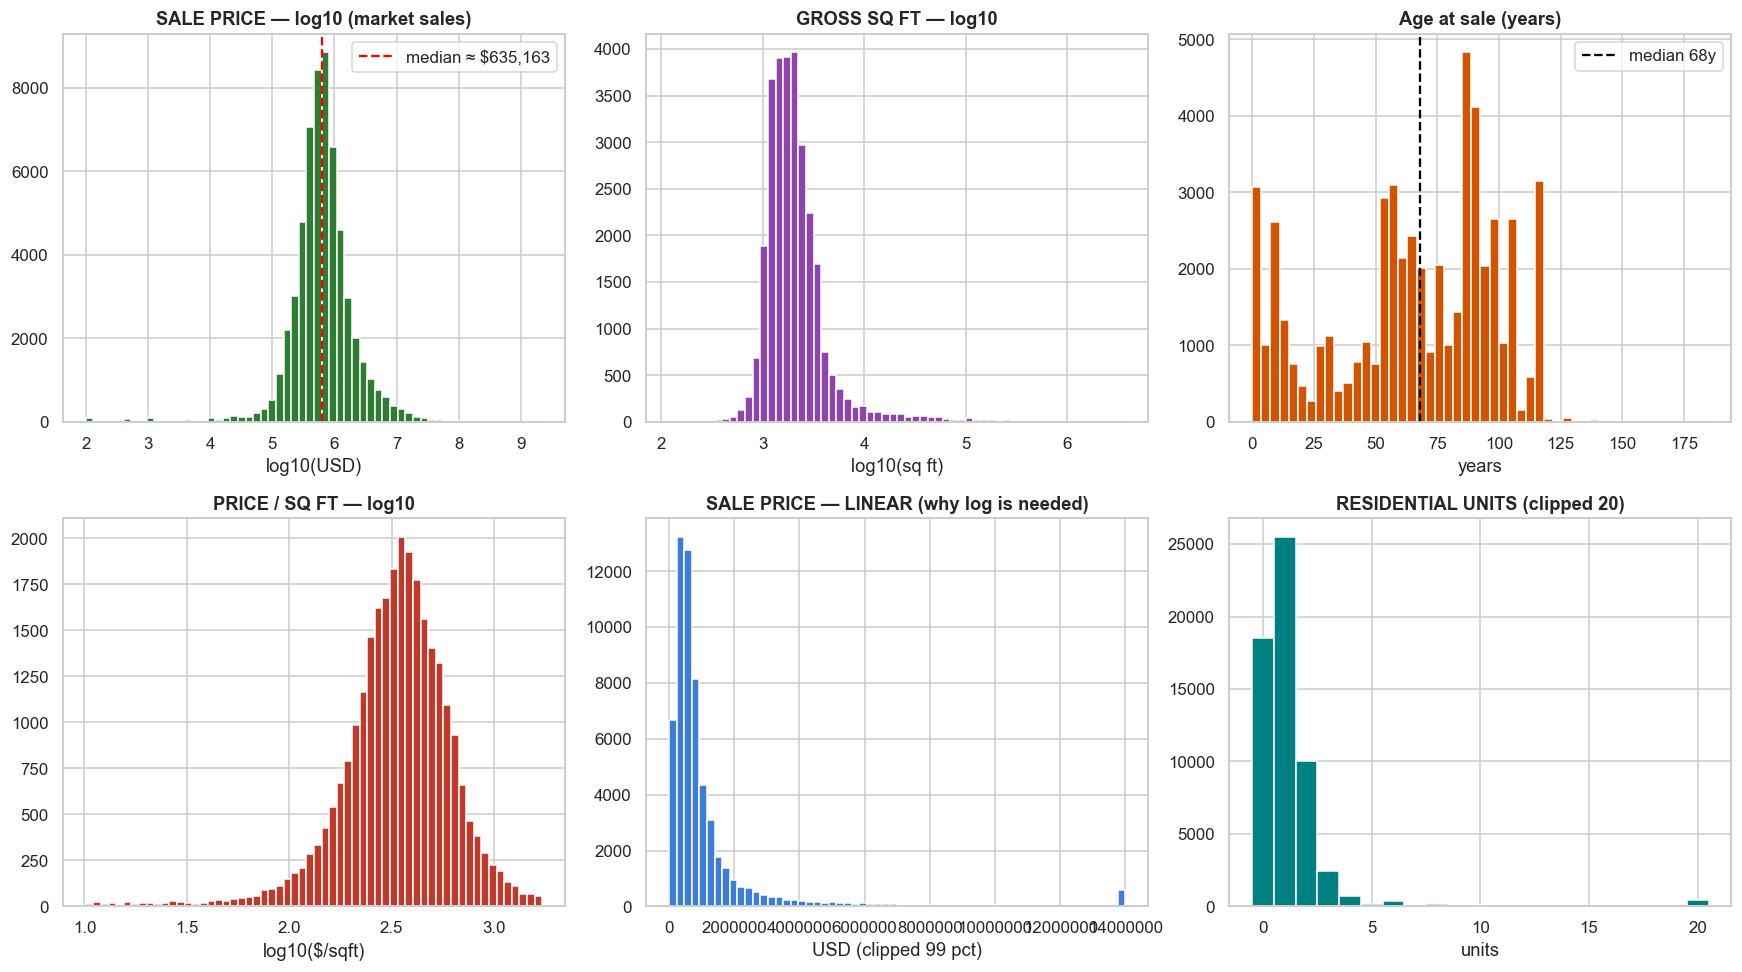

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16,9))
axes = axes.flatten()

# (a) log price
axes[0].hist(mk['log10_sale_price'].dropna(), bins=60, color='#2e7d32', edgecolor='white')
axes[0].axvline(mk['log10_sale_price'].median(), color='red', ls='--',
                label=f'median ≈ ${10**mk["log10_sale_price"].median():,.0f}')
axes[0].set_title('SALE PRICE — log10 (market sales)')
axes[0].set_xlabel('log10(USD)'); axes[0].legend()

# (b) log gross sqft
sub = mk['GROSS SQUARE FEET'].dropna(); sub = sub[sub>100]
axes[1].hist(np.log10(sub), bins=60, color='#8e44ad', edgecolor='white')
axes[1].set_title('GROSS SQ FT — log10'); axes[1].set_xlabel('log10(sq ft)')

# (c) age
age = mk['AGE_AT_SALE'].dropna(); age = age[(age>=0)&(age<=200)]
axes[2].hist(age, bins=50, color='#d35400', edgecolor='white')
axes[2].axvline(age.median(), color='black', ls='--', label=f'median {age.median():.0f}y')
axes[2].set_title('Age at sale (years)'); axes[2].set_xlabel('years'); axes[2].legend()

# (d) log price-per-sqft
ppsf = mk['PRICE_PER_SQFT'].dropna()
ppsf = ppsf[(ppsf>10) & (ppsf<ppsf.quantile(0.99))]
axes[3].hist(np.log10(ppsf), bins=60, color='#c0392b', edgecolor='white')
axes[3].set_title('PRICE / SQ FT — log10'); axes[3].set_xlabel('log10($/sqft)')

# (e) linear price (shows the problem the log plot solves)
axes[4].hist(mk['SALE PRICE'].clip(upper=mk['SALE PRICE'].quantile(0.99)), bins=60,
             color='#3b7dd8', edgecolor='white')
axes[4].set_title('SALE PRICE — LINEAR (why log is needed)'); axes[4].set_xlabel('USD (clipped 99 pct)')
axes[4].ticklabel_format(style='plain', axis='x')

# (f) residential units (discrete)
ru = mk['RESIDENTIAL UNITS'].clip(upper=20)
axes[5].hist(ru, bins=np.arange(-0.5,21,1), color='teal', edgecolor='white')
axes[5].set_title('RESIDENTIAL UNITS (clipped 20)'); axes[5].set_xlabel('units')

plt.tight_layout(); plt.savefig(FIG/'1_univariate_hist.png'); plt.show()

**Insights (univariate continuous):**
- `SALE PRICE` skew ≈ 20; log10 collapses it to near-symmetric — canonical log-normal. Median ≈ $620K dominates reporting.
- `GROSS SQ FT` log-normal; bulk 1k–3k sq ft (residential), long tail = commercial buildings.
- `AGE AT SALE` is **bimodal** — prewar (~100y, 1920s-built) + postwar cohort. A single "average age" is misleading.
- `PRICE/SQ FT` log-normal in $/sqft — the right feature for cross-property comparability.
- Linear price histogram (panel e) is visually uninformative → confirms log axis necessity.


## 1F. Discrete numerics — value counts

In [7]:
disc = ['RESIDENTIAL UNITS','COMMERCIAL UNITS','TOTAL UNITS']
print(mk[disc].agg(['mean','median','std','min','max']).round(2))
print()
for c in disc:
    vc = mk[c].value_counts().head(8)
    print(f'{c} — top values:')
    print(vc.to_string()); print()

        RESIDENTIAL UNITS  COMMERCIAL UNITS  TOTAL UNITS
mean                 1.70              0.15         1.87
median               1.00              0.00         1.00
std                 14.11              9.74        17.25
min                  0.00              0.00         0.00
max               1844.00           2261.00      2261.00

RESIDENTIAL UNITS — top values:
RESIDENTIAL UNITS
1    25500
0    18533
2    10037
3     2437
4      692
6      363
8      145
5      134

COMMERCIAL UNITS — top values:
COMMERCIAL UNITS
0    56009
1     1886
2      422
3      129
4       79
5       47
6       38
8       18

TOTAL UNITS — top values:
TOTAL UNITS
1    26741
0    16547
2     9972
3     2877
4      781
6      400
5      216
8      165



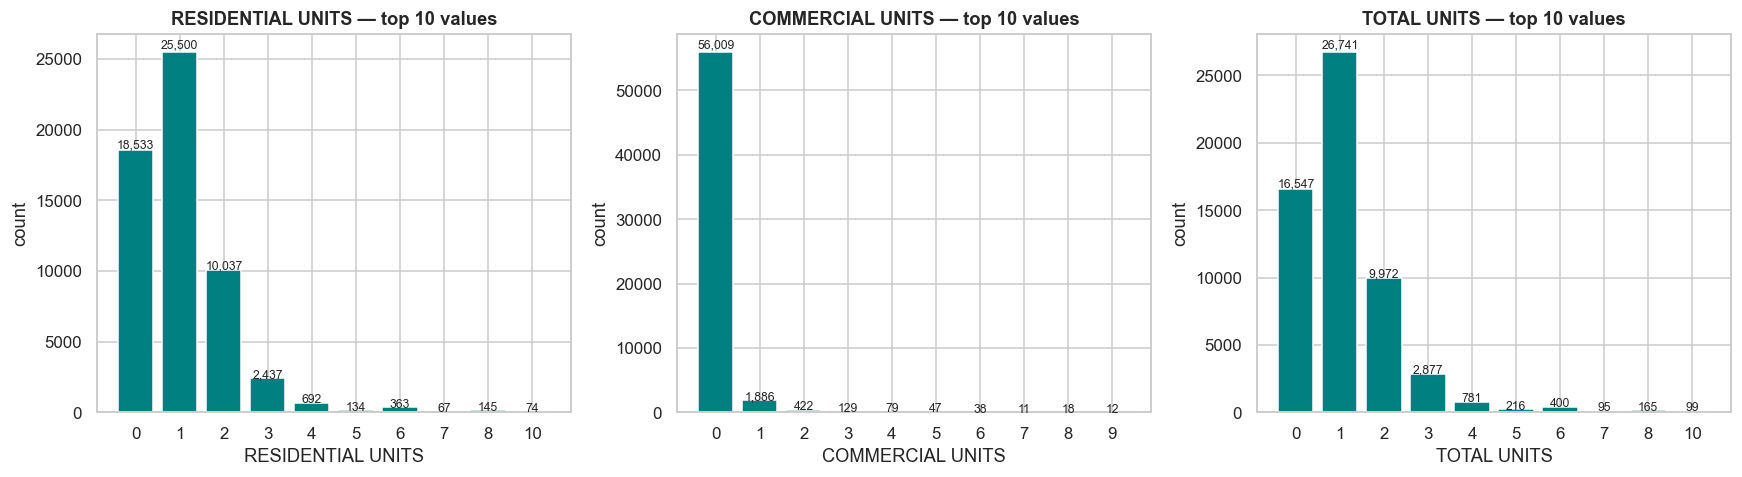

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for i,c in enumerate(disc):
    top = mk[c].value_counts().head(10).sort_index()
    ax[i].bar(top.index.astype(str), top.values, color='teal', edgecolor='white')
    ax[i].set_title(f'{c} — top 10 values'); ax[i].set_xlabel(c); ax[i].set_ylabel('count')
    for j,(x,y) in enumerate(zip(top.index.astype(str),top.values)):
        ax[i].text(j, y*1.01, f'{y:,}', ha='center', fontsize=8)
plt.tight_layout(); plt.savefig(FIG/'1_univariate_discrete.png'); plt.show()

**Insights:** 1–3 residential units dominate → dataset is overwhelmingly small residential. Commercial units ≈ 0 for most. `TOTAL UNITS` ≈ `RESIDENTIAL UNITS` for the bulk.

## 1G. Categorical — borough + building class + tax class

In [9]:
cat = ['BOROUGH_NAME','BUILDING CLASS CATEGORY','TAX CLASS AT PRESENT']
for c in cat:
    vc = mk[c].value_counts()
    pct = (vc/len(mk)*100).round(1)
    print(f'\n{c}  ({mk[c].nunique()} unique):')
    print(pd.DataFrame({'count':vc,'pct':pct}).head(8))


BOROUGH_NAME  (5 unique):
               count   pct
BOROUGH_NAME              
Queens         18151  30.9
Brooklyn       15369  26.2
Manhattan      14252  24.3
Staten Island   5881  10.0
Bronx           5060   8.6

BUILDING CLASS CATEGORY  (46 unique):
                                 count   pct
BUILDING CLASS CATEGORY                     
01 ONE FAMILY DWELLINGS          12724  21.7
10 COOPS - ELEVATOR APARTMENTS   11524  19.6
13 CONDOS - ELEVATOR APARTMENTS  10266  17.5
02 TWO FAMILY DWELLINGS           9912  16.9
09 COOPS - WALKUP APARTMENTS      2504   4.3
03 THREE FAMILY DWELLINGS         2328   4.0
07 RENTALS - WALKUP APARTMENTS    1745   3.0
04 TAX CLASS 1 CONDOS             1251   2.1

TAX CLASS AT PRESENT  (10 unique):
                      count   pct
TAX CLASS AT PRESENT             
2                     25692  43.8
1                     25020  42.6
4                      2489   4.2
2C                     1543   2.6
2A                     1254   2.1
1A                   

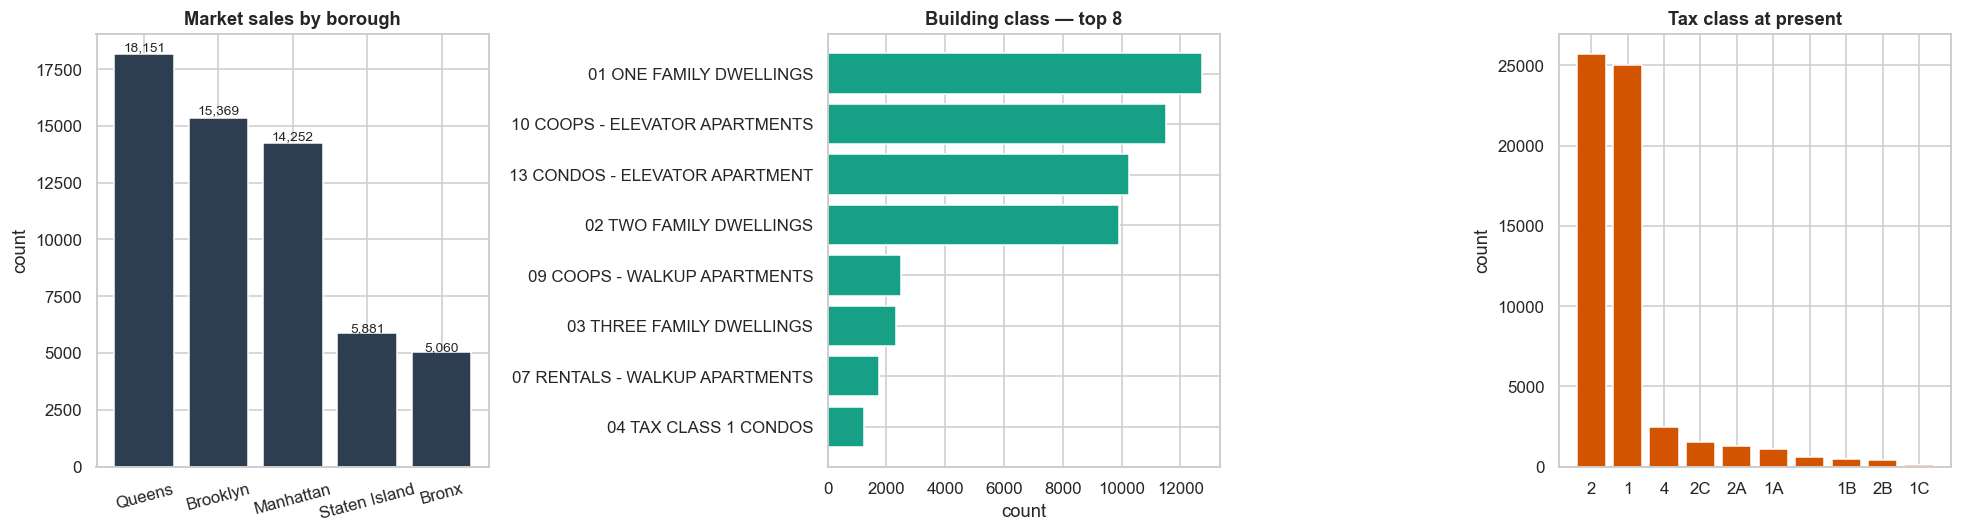

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

bor = mk['BOROUGH_NAME'].value_counts()
ax[0].bar(bor.index, bor.values, color='#2c3e50')
ax[0].set_title('Market sales by borough'); ax[0].set_ylabel('count')
for i,v in enumerate(bor.values): ax[0].text(i, v*1.01, f'{v:,}', ha='center', fontsize=9)
plt.setp(ax[0].get_xticklabels(), rotation=15)

bcc = (mk['BUILDING CLASS CATEGORY'].str.strip().value_counts().head(8)[::-1])
ax[1].barh([b[:30] for b in bcc.index], bcc.values, color='#16a085')
ax[1].set_title('Building class — top 8'); ax[1].set_xlabel('count')

tc = mk['TAX CLASS AT PRESENT'].value_counts()
ax[2].bar(tc.index, tc.values, color='#d35400')
ax[2].set_title('Tax class at present'); ax[2].set_ylabel('count')

plt.tight_layout(); plt.savefig(FIG/'1_univariate_cat.png'); plt.show()

**Insights (categorical):**
- **Queens + Brooklyn = ~60%** of market sales. Manhattan ~18k rows, Staten Island + Bronx are thinnest — sample weight matters for borough claims.
- **1-family + 2-family + 3-family homes ≈ 70%** of transactions — this is primarily a residential resale dataset.
- **Tax class 1** (small residential 1–3 units) dominates, consistent with building class breakdown.

---
# PART 2 — Bivariate Analysis
| Combination | Tools |
|---|---|
| Numeric × Numeric | Spearman corrmat + log-log scatter + binned aggregates |
| Numeric × Categorical | Boxplot on log scale + grouped bar on median |
| Categorical × Categorical | Crosstab + heatmap + chi² association |


## 2A. Numeric × Numeric — correlation matrix
**Spearman** chosen over Pearson: sale price skew ≈ 20, sqft skew heavy-tailed. Pearson under-estimates rank associations when both vars are skewed.


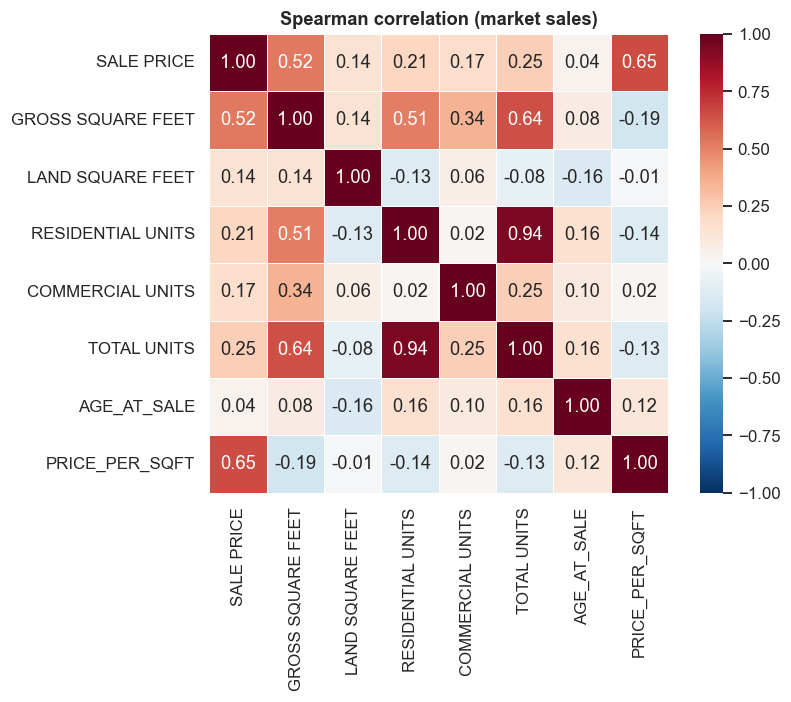


Top Spearman correlations with SALE PRICE:
PRICE_PER_SQFT       0.654
GROSS SQUARE FEET    0.525
TOTAL UNITS          0.246
RESIDENTIAL UNITS    0.211
COMMERCIAL UNITS     0.172
LAND SQUARE FEET     0.143
AGE_AT_SALE          0.038
Name: SALE PRICE, dtype: float64


In [11]:
corr_cols = ['SALE PRICE','GROSS SQUARE FEET','LAND SQUARE FEET',
             'RESIDENTIAL UNITS','COMMERCIAL UNITS','TOTAL UNITS',
             'AGE_AT_SALE','PRICE_PER_SQFT']
corr = mk[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8,6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True, ax=ax)
ax.set_title('Spearman correlation (market sales)')
plt.tight_layout(); plt.savefig(FIG/'2_corr_matrix.png'); plt.show()

print('\nTop Spearman correlations with SALE PRICE:')
print(corr['SALE PRICE'].drop('SALE PRICE').sort_values(ascending=False).round(3))

**Insights:**
- `GROSS SQ FT` is the strongest individual numeric predictor (Spearman ρ ≈ 0.5–0.7).
- Unit counts are **collinear** (ρ > 0.8 between RESIDENTIAL / TOTAL) — redundancy for modeling; drop one.
- `AGE_AT_SALE` shows **weak linear correlation with price** — but that hides a U-shape (see 2B).
- `PRICE/SQ FT` largely decorrelates from raw price and sqft — the clean per-unit feature.

## 2B. Numeric × Numeric — log-log scatter (price ~ sqft)

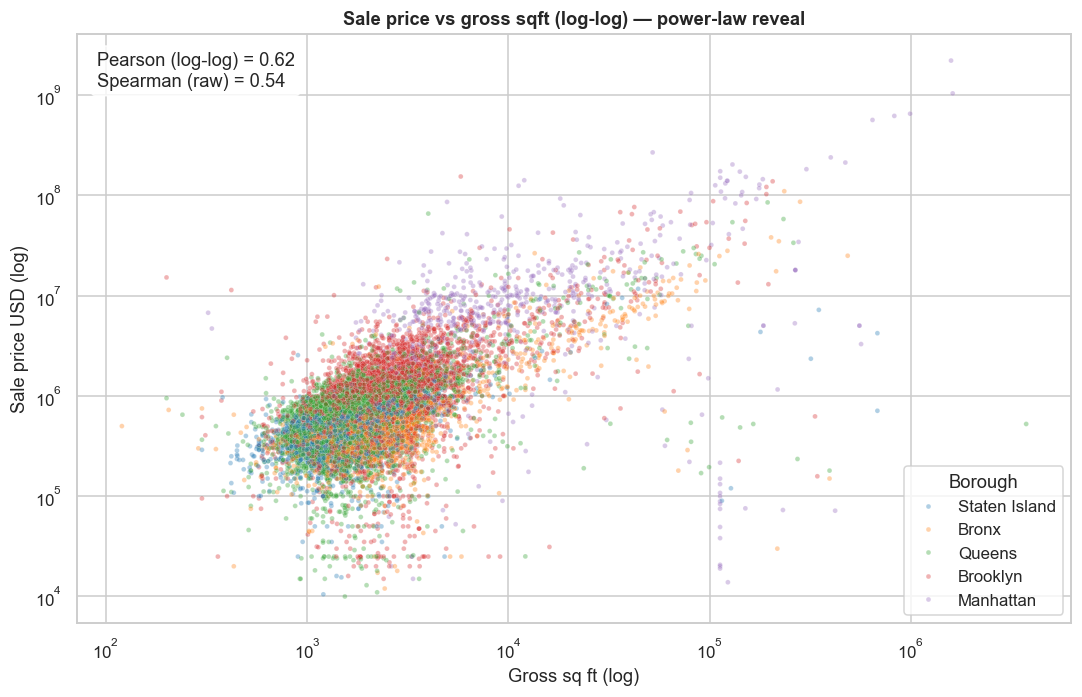

In [12]:
sub = mk.dropna(subset=['GROSS SQUARE FEET','SALE PRICE'])
sub = sub[(sub['GROSS SQUARE FEET']>100)&(sub['SALE PRICE']>1e4)]
samp = sub.sample(n=min(20000, len(sub)), random_state=42)
order=['Staten Island','Bronx','Queens','Brooklyn','Manhattan']

fig, ax = plt.subplots(figsize=(10,6.5))
sns.scatterplot(data=samp, x='GROSS SQUARE FEET', y='SALE PRICE',
                hue='BOROUGH_NAME', hue_order=order, palette='tab10',
                alpha=0.35, s=10, ax=ax)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Sale price vs gross sqft (log-log) — power-law reveal')
ax.set_xlabel('Gross sq ft (log)'); ax.set_ylabel('Sale price USD (log)')
ax.legend(title='Borough', loc='lower right')

pear,_  = stats.pearsonr (np.log10(sub['GROSS SQUARE FEET']), np.log10(sub['SALE PRICE']))
spear,_ = stats.spearmanr(sub['GROSS SQUARE FEET'], sub['SALE PRICE'])
ax.text(0.02, 0.97, f'Pearson (log-log) = {pear:.2f}\nSpearman (raw) = {spear:.2f}',
        transform=ax.transAxes, va='top', bbox=dict(boxstyle='round', alpha=0.8, facecolor='white'))
plt.tight_layout(); plt.savefig(FIG/'2_price_vs_sqft_loglog.png'); plt.show()

**Insight:** ~linear on log-log ⇒ price ∝ sqft^β (power law) — the canonical real-estate pricing relationship. Borough clouds stratify vertically: Manhattan an order of magnitude above Bronx/SI at every size. Modeling implication: use **log(price) ~ log(sqft) + borough + …**, never raw.

## 2C. Age × price — binned (reveals U-shape hidden by raw correlation)

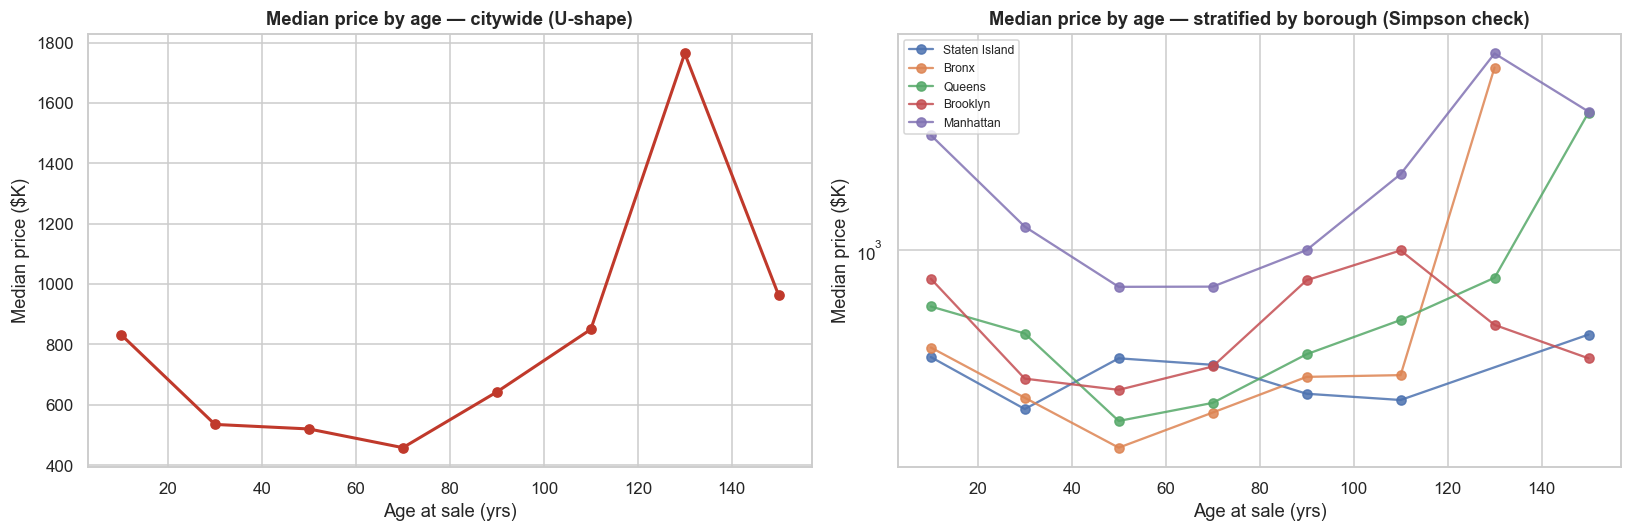

In [13]:
sub = mk.dropna(subset=['AGE_AT_SALE','SALE PRICE','BOROUGH_NAME'])
sub = sub[(sub['AGE_AT_SALE'].between(0,160))]
bins = list(range(0,161,20))
sub['age_bin'] = pd.cut(sub['AGE_AT_SALE'], bins=bins)

agg_all = sub.groupby('age_bin', observed=True)['SALE PRICE'].median().reset_index()
agg_all['mid'] = agg_all['age_bin'].apply(lambda x: x.mid)

agg_bor = sub.groupby(['age_bin','BOROUGH_NAME'], observed=True)['SALE PRICE'].median().reset_index()
agg_bor['mid'] = agg_bor['age_bin'].apply(lambda x: x.mid)

fig, ax = plt.subplots(1, 2, figsize=(15,5))
ax[0].plot(agg_all['mid'], agg_all['SALE PRICE']/1e3, marker='o', color='#c0392b', linewidth=2)
ax[0].set_title('Median price by age — citywide (U-shape)')
ax[0].set_xlabel('Age at sale (yrs)'); ax[0].set_ylabel('Median price ($K)')

for b in order:
    d=agg_bor[agg_bor['BOROUGH_NAME']==b]
    ax[1].plot(d['mid'], d['SALE PRICE']/1e3, marker='o', label=b, alpha=0.85)
ax[1].set_title('Median price by age — stratified by borough (Simpson check)')
ax[1].set_xlabel('Age at sale (yrs)'); ax[1].set_ylabel('Median price ($K)')
ax[1].set_yscale('log'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/'2_age_price.png'); plt.show()

**Insight (age — Simpson's paradox warning):**
- Citywide: non-monotonic **U-shape**. 0–20y new-build premium; 80–120y prewar premium; 40–60y postwar trough.
- Stratified: within-borough, age effect is weak. The citywide "old = expensive" pattern is largely driven by **prewar Manhattan stock**, not a universal rule. Concluding "older = pricier" without borough control is a Simpson's-paradox error.
- Modeling implication: use **splines/binned age × borough interaction**, not linear age.

## 2D. Numeric × Categorical — price by borough (boxplot log scale)

/var/folders/9t/bpzw4p1154d9m6xxwv2b5s5r0000gn/T/ipykernel_78446/2787641802.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mk, x='BOROUGH_NAME', y='log10_sale_price', order=order,
/var/folders/9t/bpzw4p1154d9m6xxwv2b5s5r0000gn/T/ipykernel_78446/2787641802.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ppsf, x='BOROUGH_NAME', y='PRICE_PER_SQFT', order=psf_order,


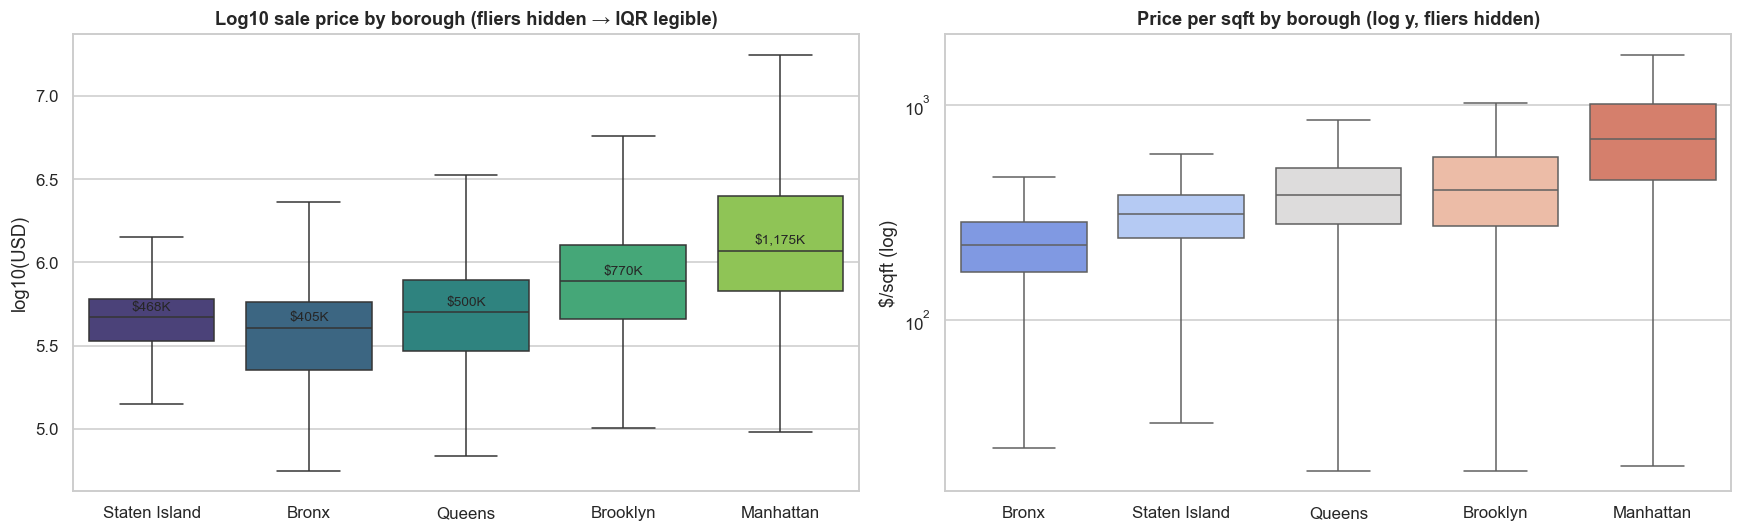

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(16,5))

sns.boxplot(data=mk, x='BOROUGH_NAME', y='log10_sale_price', order=order,
            showfliers=False, palette='viridis', ax=ax[0])
ax[0].set_title('Log10 sale price by borough (fliers hidden → IQR legible)')
ax[0].set_ylabel('log10(USD)'); ax[0].set_xlabel('')
for i,b in enumerate(order):
    med = mk.loc[mk['BOROUGH_NAME']==b,'log10_sale_price'].median()
    ax[0].text(i, med+0.04, f'${10**med/1e3:,.0f}K', ha='center', fontsize=9)

ppsf = mk.dropna(subset=['PRICE_PER_SQFT'])
ppsf = ppsf[ppsf['PRICE_PER_SQFT'].between(20, ppsf['PRICE_PER_SQFT'].quantile(0.99))]
psf_order = ppsf.groupby('BOROUGH_NAME')['PRICE_PER_SQFT'].median().sort_values().index.tolist()
sns.boxplot(data=ppsf, x='BOROUGH_NAME', y='PRICE_PER_SQFT', order=psf_order,
            showfliers=False, palette='coolwarm', ax=ax[1])
ax[1].set_yscale('log')
ax[1].set_title('Price per sqft by borough (log y, fliers hidden)')
ax[1].set_ylabel('$/sqft (log)'); ax[1].set_xlabel('')

plt.tight_layout(); plt.savefig(FIG/'2_price_borough.png'); plt.show()

**Insights (borough pricing):**
- Manhattan median ~2–3× Brooklyn and ~5× Bronx. Non-overlapping IQRs between Manhattan and outer boroughs.
- Price-per-sqft ordering: **Manhattan > Brooklyn > Queens > Staten Island > Bronx**. The borough premium is **real at the $/sqft level**, not just a size artifact.
- Staten Island cheaper **per-sqft** than Queens despite similar absolute prices — suburban lot sizes inflate SI totals.

## 2E. Price by building class (top 6, log y)

/var/folders/9t/bpzw4p1154d9m6xxwv2b5s5r0000gn/T/ipykernel_78446/4215924553.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='bcc_short', y='log10_sale_price', order=cls_order,


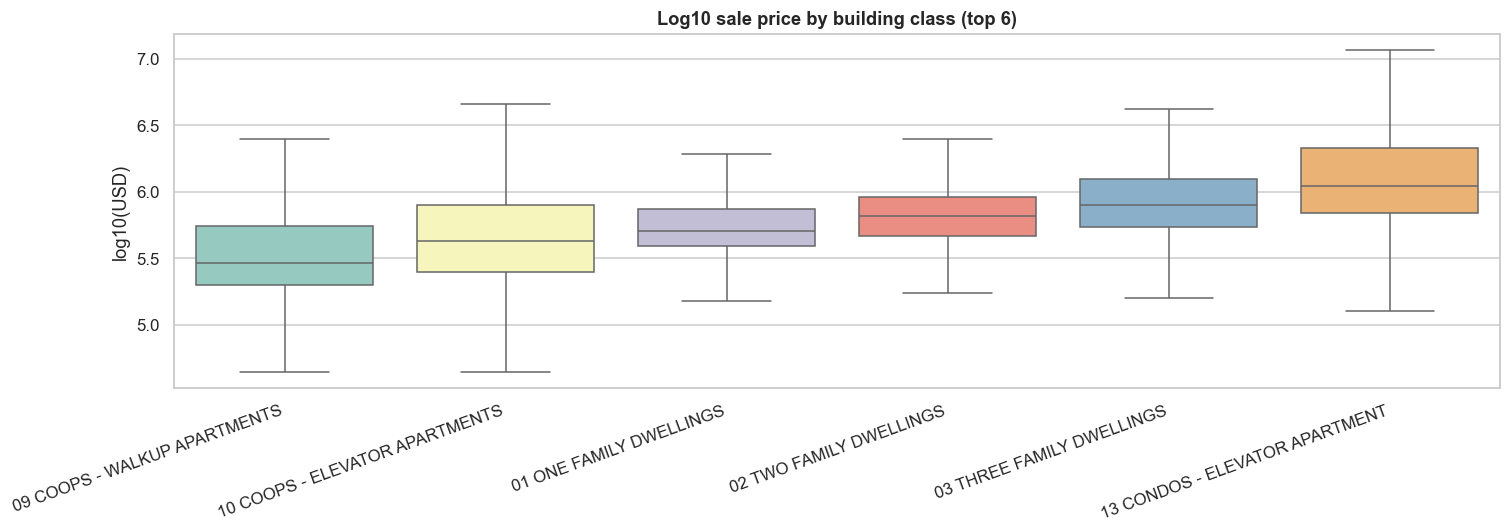

In [15]:
top6 = mk['BUILDING CLASS CATEGORY'].value_counts().head(6).index
sub = mk[mk['BUILDING CLASS CATEGORY'].isin(top6)].copy()
sub['bcc_short'] = sub['BUILDING CLASS CATEGORY'].str[:30]
cls_order = sub.groupby('bcc_short')['log10_sale_price'].median().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(14,5))
sns.boxplot(data=sub, x='bcc_short', y='log10_sale_price', order=cls_order,
            showfliers=False, palette='Set3', ax=ax)
ax.set_title('Log10 sale price by building class (top 6)')
ax.set_ylabel('log10(USD)'); ax.set_xlabel('')
plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.savefig(FIG/'2_price_buildingclass.png'); plt.show()

**Insight:** Walkup + elevator rental apartment categories have wider IQR because they price **per-building** (multiple units). 1-family homes tightest distribution. Condo categories scale with unit size + borough, not a universal "condo premium".

## 2F. Categorical × Categorical — borough × class, borough × tax class

borough × class: chi2=20366  dof=16  p=0.0e+00  Cramer V=0.329


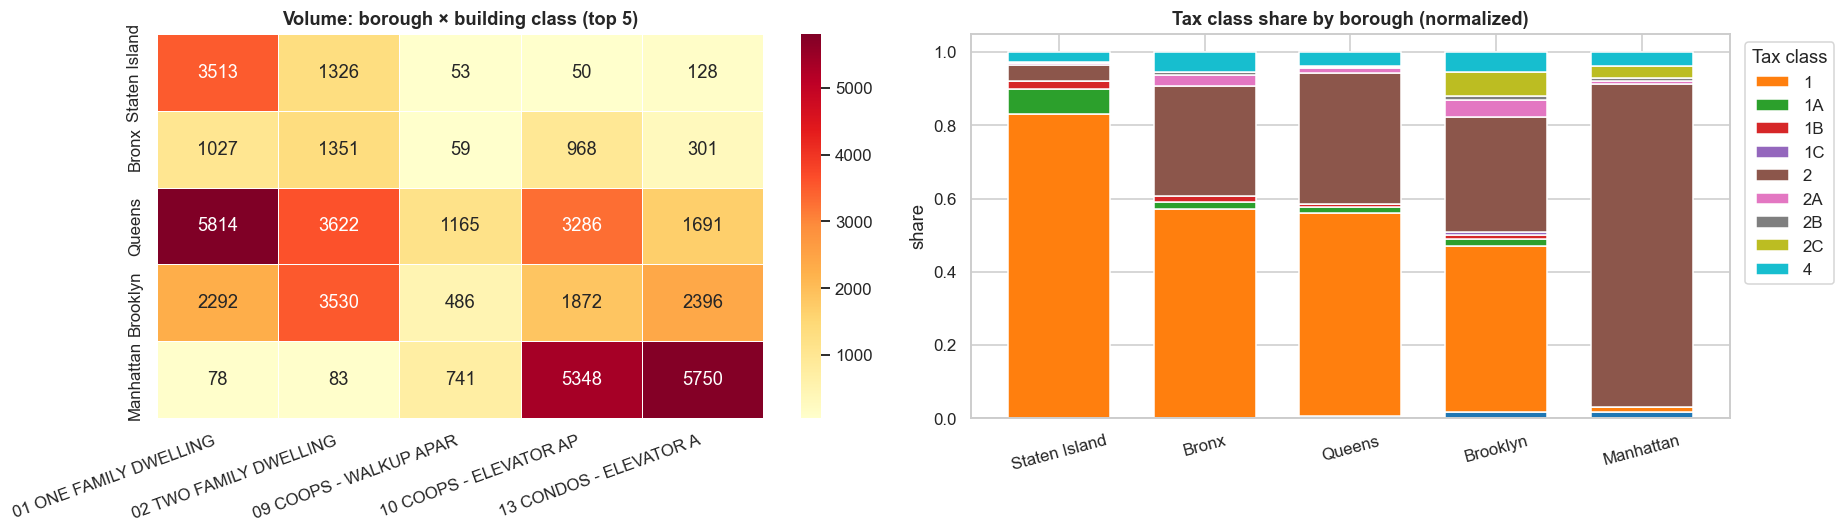

In [16]:
top5 = mk['BUILDING CLASS CATEGORY'].value_counts().head(5).index
sub = mk[mk['BUILDING CLASS CATEGORY'].isin(top5)].copy()
sub['bcc_short'] = sub['BUILDING CLASS CATEGORY'].str[:22]
ct = pd.crosstab(sub['BOROUGH_NAME'], sub['bcc_short']).reindex(order)

fig, ax = plt.subplots(1, 2, figsize=(17,5))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax[0])
ax[0].set_title('Volume: borough × building class (top 5)')
ax[0].set_xlabel(''); ax[0].set_ylabel('')
plt.setp(ax[0].get_xticklabels(), rotation=20, ha='right')

ct2 = pd.crosstab(mk['BOROUGH_NAME'], mk['TAX CLASS AT PRESENT']).reindex(order)
ct2_norm = ct2.div(ct2.sum(axis=1), axis=0)
ct2_norm.plot(kind='bar', stacked=True, ax=ax[1], colormap='tab10',
              edgecolor='white', width=0.7)
ax[1].set_title('Tax class share by borough (normalized)')
ax[1].set_ylabel('share'); ax[1].set_xlabel('')
ax[1].legend(title='Tax class', bbox_to_anchor=(1.01,1))
plt.setp(ax[1].get_xticklabels(), rotation=15)

# chi2 for the borough × class table
chi2, p, dof, _ = stats.chi2_contingency(ct)
cramer = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape)-1)))
print(f'borough × class: chi2={chi2:.0f}  dof={dof}  p={p:.1e}  Cramer V={cramer:.3f}')

plt.tight_layout(); plt.savefig(FIG/'2_cat_cat.png'); plt.show()

**Insights (category × category):**
- Queens is 1-family-heavy; Manhattan is condo/elevator-apartment-heavy; Brooklyn mixes 1/2/3-family densely.
- Cramér V moderate → borough and building mix are **far from independent**. Any cross-borough price claim must control for product mix or it's apples-to-oranges.
- Tax class 1 dominates Queens + SI; Manhattan + Bronx skew toward tax class 2 (larger residential).

---
# PART 3 — Multivariate Analysis

| Chart | Variables | Question |
|---|---|---|
| 3A Grouped bar — $/sqft × borough × class | borough + class + $/sqft | Does borough premium hold across property types? |
| 3B Dual-axis — price + $/sqft by borough | borough + price + $/sqft | Is Manhattan's lead location or size-driven? |
| 3C Heatmap — volume × borough × month | borough + month + count | Seasonality per borough |
| 3D Line — median price × borough × month | borough + month + price | Trend differences across boroughs |
| 3E Pairplot (log-transformed) | 4 numerics + borough | Clusters + cross-relationships at a glance |


## 3A. $/sqft × borough × building class

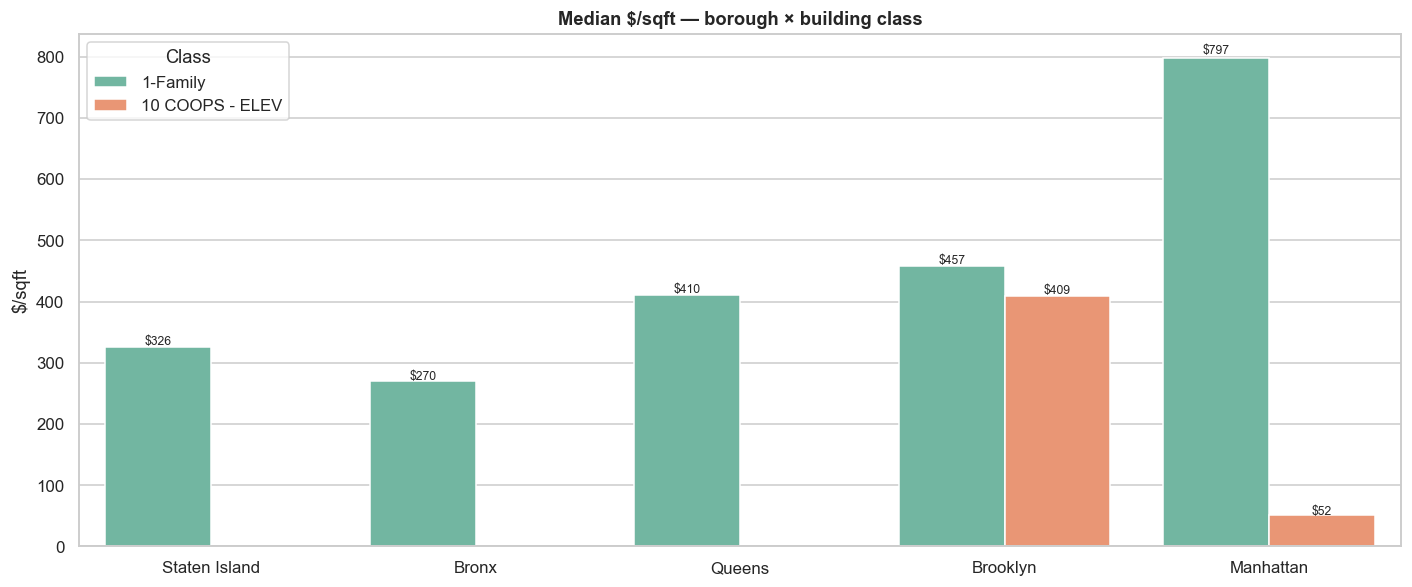

In [17]:
top3 = mk['BUILDING CLASS CATEGORY'].value_counts().head(3).index
sub = mk[mk['BUILDING CLASS CATEGORY'].isin(top3)].dropna(subset=['PRICE_PER_SQFT']).copy()
sub = sub[sub['PRICE_PER_SQFT'].between(20, sub['PRICE_PER_SQFT'].quantile(0.99))]
label = {'01 ONE FAMILY DWELLINGS':'1-Family',
         '02 TWO FAMILY DWELLINGS':'2-Family',
         '03 THREE FAMILY DWELLINGS':'3-Family'}
sub['bcc'] = sub['BUILDING CLASS CATEGORY'].map(lambda x: label.get(x.strip(), x[:15]))
grp = sub.groupby(['BOROUGH_NAME','bcc'])['PRICE_PER_SQFT'].median().reset_index()

fig, ax = plt.subplots(figsize=(13,5.5))
sns.barplot(data=grp, x='BOROUGH_NAME', y='PRICE_PER_SQFT',
            hue='bcc', order=order, palette='Set2', ax=ax)
ax.set_title('Median $/sqft — borough × building class'); ax.set_ylabel('$/sqft')
ax.set_xlabel(''); ax.legend(title='Class')
for p in ax.patches:
    h=p.get_height()
    if h and not np.isnan(h):
        ax.text(p.get_x()+p.get_width()/2, h*1.01, f'${h:.0f}', ha='center', fontsize=8)
plt.tight_layout(); plt.savefig(FIG/'3_psqft_bor_x_cls.png'); plt.show()

**Insight:** Borough ordering (Manhattan > Brooklyn > Queens > SI > Bronx) holds **across all three building classes** — location premium is structural, not class-specific. Gap **width** varies: 1-family class compresses the borough gap (~2–3×); wider for multi-family.

## 3B. Dual-axis — absolute price vs $/sqft by borough

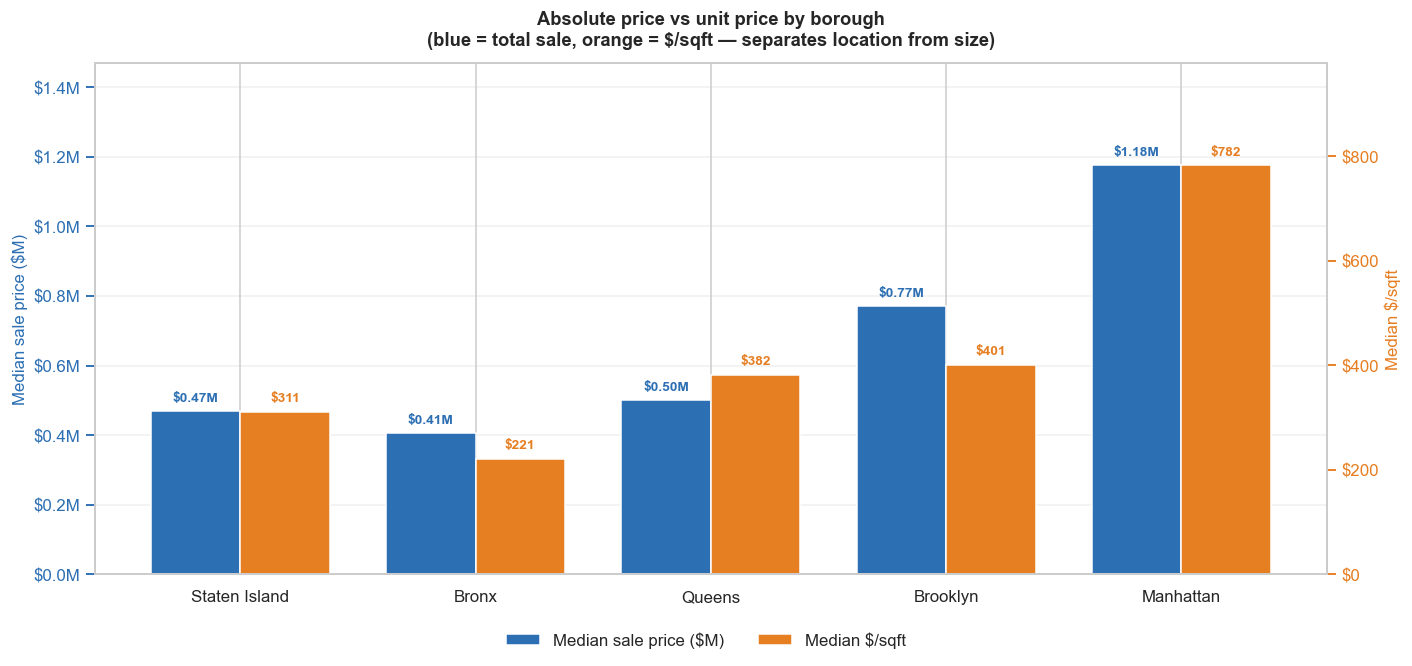

In [18]:
bs = (mk.groupby('BOROUGH_NAME')
        .agg(median_price=('SALE PRICE','median'),
             median_psqft=('PRICE_PER_SQFT','median'),
             n=('SALE PRICE','size'))
        .reindex(order).reset_index())

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()
x = np.arange(len(order)); w = 0.38

b1 = ax1.bar(x - w/2, bs['median_price']/1e6, w,
             color='#2c6fb3', edgecolor='white', label='Median sale price ($M)')
b2 = ax2.bar(x + w/2, bs['median_psqft'], w,
             color='#e67e22', edgecolor='white', label='Median $/sqft')

ax1.set_xticks(x); ax1.set_xticklabels(order, fontsize=11)
ax1.set_ylabel('Median sale price ($M)', color='#2c6fb3', fontsize=11)
ax2.set_ylabel('Median $/sqft',           color='#e67e22', fontsize=11)
ax1.tick_params(axis='y', colors='#2c6fb3')
ax2.tick_params(axis='y', colors='#e67e22')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.1f}M'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.0f}'))

# 20% headroom above tallest bar so labels + legend never collide
ax1.set_ylim(0, bs['median_price'].max()/1e6 * 1.25)
ax2.set_ylim(0, bs['median_psqft'].max()     * 1.25)

ax1.set_title('Absolute price vs unit price by borough\n(blue = total sale, orange = $/sqft — separates location from size)',
              fontsize=12, pad=12)

# data-label offsets (fraction of y-axis range) so they always sit above bars
y1_pad = ax1.get_ylim()[1] * 0.015
y2_pad = ax2.get_ylim()[1] * 0.015
for p in b1:
    ax1.text(p.get_x()+p.get_width()/2, p.get_height()+y1_pad,
             f'${p.get_height():.2f}M', ha='center', va='bottom',
             color='#2c6fb3', fontsize=9, fontweight='bold')
for p in b2:
    ax2.text(p.get_x()+p.get_width()/2, p.get_height()+y2_pad,
             f'${p.get_height():.0f}', ha='center', va='bottom',
             color='#e67e22', fontsize=9, fontweight='bold')

# legend OUTSIDE plot area (bottom) — no collision with bars
h1,l1 = ax1.get_legend_handles_labels()
h2,l2 = ax2.get_legend_handles_labels()
fig.legend(h1+h2, l1+l2, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=11)

ax1.grid(axis='y', alpha=0.3); ax2.grid(False)
plt.tight_layout(rect=[0,0.04,1,1])
plt.savefig(FIG/'3_dual_axis.png', bbox_inches='tight'); plt.show()

**Insight:** Manhattan high on **both** axes → premium is real, not just larger properties. Staten Island shows high absolute price ≈ low $/sqft → suburban **lot size** inflates totals. Brooklyn's $/sqft > Queens but absolute price similar → Brooklyn buyer pays more per unit of space.

## 3C. Volume heatmap — borough × month

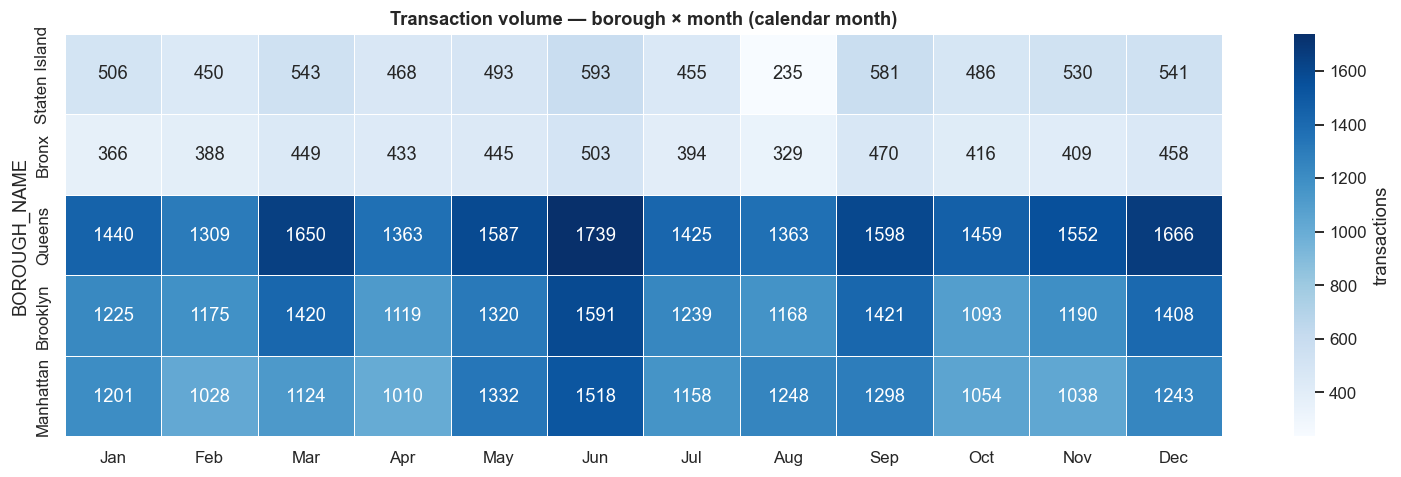

In [19]:
mk['sale_month_num'] = mk['SALE DATE'].dt.month
vol = (mk.pivot_table(values='SALE PRICE', index='BOROUGH_NAME',
                      columns='sale_month_num', aggfunc='count')
         .reindex(order))
vol.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14,4.5))
sns.heatmap(vol, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            ax=ax, cbar_kws={'label':'transactions'})
ax.set_title('Transaction volume — borough × month (calendar month)')
plt.tight_layout(); plt.savefig(FIG/'3_volume_heatmap.png'); plt.show()

**Insights:** Queens + Brooklyn dominate every month — structural, not seasonal. Spring/summer volume peaks (May–Aug) citywide → classic NYC listing cycle. Staten Island shows relative volatility (thin market).

## 3D. Monthly median price by borough (trend)

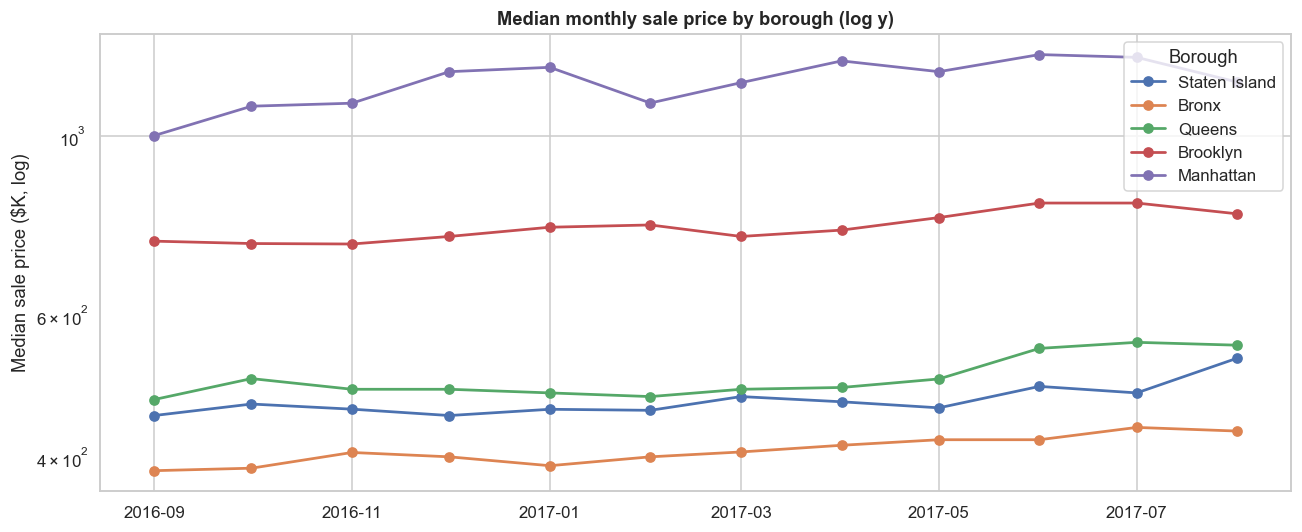

In [20]:
ts = mk.dropna(subset=['SALE PRICE']).copy()
monthly = (ts.groupby([ts['SALE DATE'].dt.to_period('M'),'BOROUGH_NAME'])
             ['SALE PRICE'].median().reset_index())
monthly['month'] = monthly['SALE DATE'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12,5))
for b in order:
    d = monthly[monthly['BOROUGH_NAME']==b]
    ax.plot(d['month'], d['SALE PRICE']/1e3, marker='o', label=b, linewidth=1.8)
ax.set_yscale('log')
ax.set_title('Median monthly sale price by borough (log y)')
ax.set_ylabel('Median sale price ($K, log)'); ax.legend(title='Borough')
plt.tight_layout(); plt.savefig(FIG/'3_trend_borough.png'); plt.show()

**Insight:** Borough ordering stable across all 12 months — no convergence/divergence trend. Manhattan month-to-month volatility largest (luxury mix shifts). Outer boroughs flat-stable. 12-mo window too short to call a cycle.

## 3E. Neighborhood market map — bubble chart
Each dot = a neighborhood (≥50 sales). X = median $/sqft (unit price). Y = median sale price (total).
Color = borough. Bubble size = transaction volume.

**Reads in one glance:** clusters of neighborhoods with similar market profiles, borough separation, and which neighborhoods are outliers in their borough.

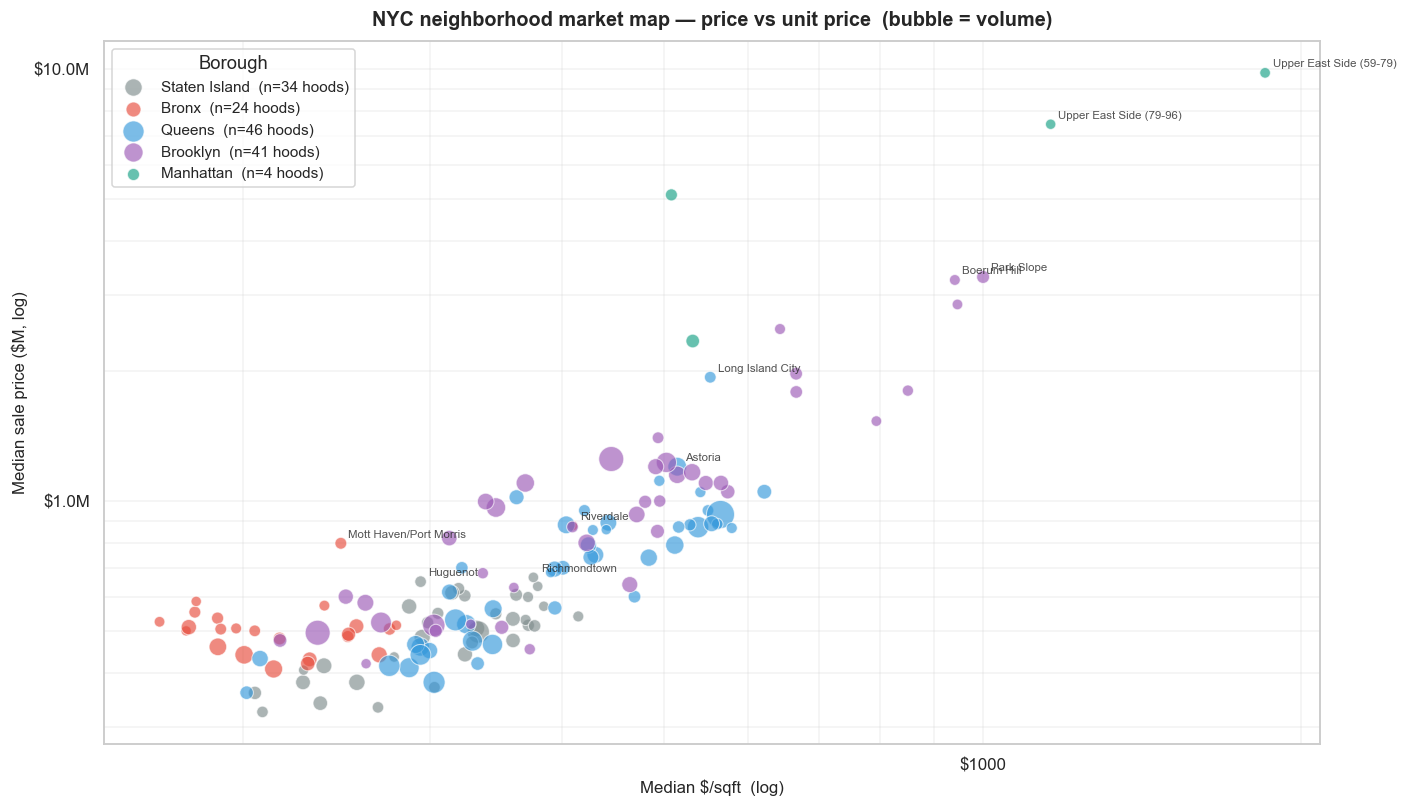


Top 5 priciest neighborhoods (by median sale price):
BOROUGH_NAME            NEIGHBORHOOD  med_price   med_psqft   n
   Manhattan UPPER EAST SIDE (59-79)  9800000.0 1850.000000  59
   Manhattan UPPER EAST SIDE (79-96)  7450000.0 1159.874608  53
   Manhattan             HARLEM-EAST  5112500.0  507.936020  94
    Brooklyn              PARK SLOPE  3300000.0 1001.177856 117
    Brooklyn             BOERUM HILL  3247500.0  941.493056  64

Best $/sqft value (lowest, with ≥200 sales):
BOROUGH_NAME   NEIGHBORHOOD  med_psqft  med_price   n
       Bronx      SOUNDVIEW 189.242443   459134.0 270
       Bronx WILLIAMSBRIDGE 200.383820   440000.0 304
      Queens   FAR ROCKAWAY 207.438077   431300.0 226
       Bronx     BAYCHESTER 213.655008   408000.0 288
    Brooklyn  EAST NEW YORK 235.148515   495000.0 607


In [21]:
nb_agg = (mk.dropna(subset=['PRICE_PER_SQFT','SALE PRICE'])
            .groupby(['BOROUGH_NAME','NEIGHBORHOOD'])
            .agg(med_price=('SALE PRICE','median'),
                 med_psqft=('PRICE_PER_SQFT','median'),
                 n=('SALE PRICE','size'))
            .reset_index())
nb_agg = nb_agg[nb_agg['n'] >= 50]
nb_agg = nb_agg[nb_agg['med_psqft'].between(50, 3000)]

fig, ax = plt.subplots(figsize=(13, 7.5))
palette = {'Staten Island':'#7f8c8d','Bronx':'#e74c3c','Queens':'#3498db',
           'Brooklyn':'#9b59b6','Manhattan':'#16a085'}

for b in order:
    d = nb_agg[nb_agg['BOROUGH_NAME']==b]
    ax.scatter(d['med_psqft'], d['med_price']/1e6,
               s=d['n']*0.4 + 25, alpha=0.65, color=palette[b],
               edgecolor='white', linewidth=0.7, label=f'{b}  (n={len(d)} hoods)')

# label a handful of notable neighborhoods (top-3 price per borough)
for b in order:
    top = nb_agg[nb_agg['BOROUGH_NAME']==b].nlargest(2,'med_price')
    for _,row in top.iterrows():
        ax.annotate(row['NEIGHBORHOOD'].title(),
                    (row['med_psqft'], row['med_price']/1e6),
                    fontsize=7.5, alpha=0.8,
                    xytext=(5,4), textcoords='offset points')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Median $/sqft  (log)', fontsize=11)
ax.set_ylabel('Median sale price ($M, log)', fontsize=11)
ax.set_title('NYC neighborhood market map — price vs unit price  (bubble = volume)',
             fontsize=13, pad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.1f}M' if v>=1 else f'${v*1000:.0f}K'))
ax.grid(True, which='both', alpha=0.25)
ax.legend(title='Borough', loc='upper left', frameon=True, fontsize=10)

plt.tight_layout(); plt.savefig(FIG/'3_neighborhood_map.png', bbox_inches='tight'); plt.show()

print('\nTop 5 priciest neighborhoods (by median sale price):')
print(nb_agg.nlargest(5,'med_price')[['BOROUGH_NAME','NEIGHBORHOOD','med_price','med_psqft','n']]
      .to_string(index=False))
print('\nBest $/sqft value (lowest, with ≥200 sales):')
val = nb_agg[nb_agg['n']>=200].nsmallest(5,'med_psqft')
print(val[['BOROUGH_NAME','NEIGHBORHOOD','med_psqft','med_price','n']].to_string(index=False))

**Reading the map:**
- **Borough bands** are visible — Manhattan cluster sits upper-right (high price + high $/sqft); Bronx/SI lower-left.
- **Staten Island** low $/sqft yet mid-range absolute price → suburban: lot size compensates for unit price.
- **Outlier neighborhoods inside each borough** are the annotated dots — premium pockets (e.g. Manhattan's high-end, Brooklyn's brownstone belt).
- Bubble area = volume → thin markets (Staten Island neighborhoods) vs deep ones (Queens suburbs) immediately visible.
- This single plot subsumes what a pairplot tried to show, at neighborhood granularity instead of row-level noise.

---
# EDA Summary — Key Findings

| # | Analysis | Finding | Business / modeling implication |
|---|---|---|---|
| 1 | Univariate | `SALE PRICE` skew ≈ 20, log-normal. | Use **median** citywide, **log10(price)** as model target. |
| 2 | Univariate | Age is **bimodal** (prewar + postwar cohorts). | Don't summarize age with a single mean. |
| 3 | Univariate | Deed transfers ≈ 15% of rows (price < $100). | Filter to `is_market_sale` for every price stat. |
| 4 | Univariate | 1–3 family homes ≈ 70% of volume; Queens+Brooklyn ≈ 60%. | Residential-resale dataset; sample weight concentrated outer-borough. |
| 5 | Bivariate | Spearman(price, sqft) ≈ 0.5–0.7; log-log ~linear. | Price ∝ sqft^β power law → `log(price) ~ log(sqft)`. |
| 6 | Bivariate | Age–price citywide is U-shaped; flat within borough. | **Simpson's paradox** — always stratify or interact age × borough. |
| 7 | Bivariate | Borough × class Cramér V moderate-strong. | Control for product mix before cross-borough comparisons. |
| 8 | Bivariate | Manhattan median price ≈ 2–3× Brooklyn, ≈ 5× Bronx. | Borough is first-order feature. |
| 9 | Bivariate | $/sqft ordering: Manhattan > Brooklyn > Queens > SI > Bronx. | Premium is unit-price-real, not size artifact. |
| 10 | Multivariate | Borough premium holds across 1/2/3-family classes. | Location beats product type. |
| 11 | Multivariate | SI: high absolute price but low $/sqft. | Suburban lot size inflates totals — different product. |
| 12 | Multivariate | Volume peaks May–Aug citywide; ordering stable per borough. | Seasonality in **volume**, not price trend. |
| 13 | Multivariate | 12-month window shows no convergence/divergence. | Period too short for market-cycle conclusions. |

## Handoff to statistical analysis (04)
- Test H1: Manhattan median ≠ Brooklyn median (Mann–Whitney).
- Test H2: All-borough equality (Kruskal–Wallis + ε²).
- Test H3: Age effect partial-correlated on size and stratified by borough.
- Test H4: χ² borough × class (Cramér V confirmed here).
- Forecast: monthly median price, Holt linear trend (short series → report IQR band).
- Segmentation: cluster neighborhoods on price + $/sqft + size + age + multi-family share.
